In [1]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [2]:
text =  open('/kaggle/input/tiny-shakespeare/tiny-shakespeare.txt').read()

In [3]:
vocabs = sorted(set(text))
vocabs
stoi = {}
for i,data in enumerate(vocabs):
    stoi[data] = i
itos = {i:s for s,i in stoi.items()}
itos

{0: '\n',
 1: ' ',
 2: '!',
 3: '$',
 4: '&',
 5: "'",
 6: ',',
 7: '-',
 8: '.',
 9: '3',
 10: ':',
 11: ';',
 12: '?',
 13: 'A',
 14: 'B',
 15: 'C',
 16: 'D',
 17: 'E',
 18: 'F',
 19: 'G',
 20: 'H',
 21: 'I',
 22: 'J',
 23: 'K',
 24: 'L',
 25: 'M',
 26: 'N',
 27: 'O',
 28: 'P',
 29: 'Q',
 30: 'R',
 31: 'S',
 32: 'T',
 33: 'U',
 34: 'V',
 35: 'W',
 36: 'X',
 37: 'Y',
 38: 'Z',
 39: 'a',
 40: 'b',
 41: 'c',
 42: 'd',
 43: 'e',
 44: 'f',
 45: 'g',
 46: 'h',
 47: 'i',
 48: 'j',
 49: 'k',
 50: 'l',
 51: 'm',
 52: 'n',
 53: 'o',
 54: 'p',
 55: 'q',
 56: 'r',
 57: 's',
 58: 't',
 59: 'u',
 60: 'v',
 61: 'w',
 62: 'x',
 63: 'y',
 64: 'z'}

In [4]:
#converting to int tokens
tokenized = [stoi[ch] for ch in text]

In [5]:
text[:51]

'First Citizen:\nBefore we proceed any further, hear '

In [6]:
context_size = 10
def build_dataset():
    combined = []
    for i in range(len(tokenized) - context_size -1 ):
        combined.append(tokenized[i:i+context_size+1])
    return combined

combined = build_dataset()

import random
random.shuffle(combined)

temp = torch.tensor(combined)
n1 = int(0.8 * len(combined))
n2  = int(0.9 * len(combined))

train = temp[0:n1]
test = temp[n1:n2]
val = temp[n2:]

X_train, Y_train  =  train[:,:-1], train[:,-1]
X_test, Y_test = test[:,:-1], test[:,-1]
X_val, Y_val = val[:,:-1], val[:,-1]

print(len(X_train), len(X_val), len(X_test))

892306 111539 111538


In [7]:
torch.manual_seed(42)

In [8]:
n_embedd =12
n_hidden = 100
vocab_size = len(itos)
fan_in = 10
gain = 5/3
C = torch.randn((vocab_size, n_embedd)) 

Wxh = torch.randn((n_embedd, n_hidden)) * gain *(fan_in)**-0.5 # (10,100)  Kaiming Init
Whh = torch.randn((n_hidden,n_hidden)) * 0.01# (100,100)
Who = torch.randn((n_hidden,vocab_size)) * 0.01 # (100,67)
bx = torch.randn((1,n_hidden)) * 0# (1,100)
bo = torch.randn((1,vocab_size)) * 0  #(1,67)

parameters = [C, Wxh, bx, Whh, Who, bo]
num_params = sum([p.nelement() for p in parameters])
print(num_params)

for p in parameters:
    p.requires_grad = True 

18645


In [9]:
velocity = [torch.zeros_like(C), torch.zeros_like(Wxh), torch.zeros_like(bx), torch.zeros_like(Whh), torch.zeros_like(Who), torch.zeros_like(bo)]
num_vel = sum([p.nelement() for p in velocity])
print(num_vel)

for p in velocity:
    p.requires_grad = False

18645


In [10]:
C.shape

torch.Size([67, 12])

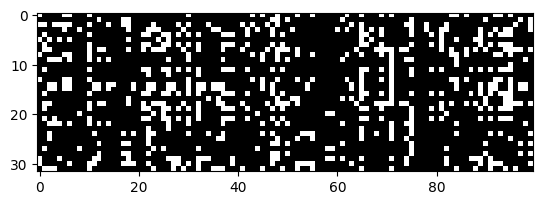

In [45]:
plt.imshow(hpreact.abs() > 2.5, cmap='gray')

In [10]:
#for finding the right learning rate
torch.set_printoptions(precision=12)
lre = torch.linspace(-3,0,1000,dtype=torch.float32)
lrs = 10 ** lre

In [11]:
#for finding the learnng rate
batch_size = 32
n_hidden = 100
steps = 200000
stepi = []
lossi = []
lri = []

for j in range(len(lrs)):
    ix = torch.randint(0, X_train.shape[0], (batch_size,))
    
    Xb = X_train[ix]
    Yb = Y_train[ix]
    
    hprev = torch.randn((batch_size,n_hidden))

    
    emb = C[Xb]
    total_loss = 0
    total_tokens = 0
    loss_manual = 0
    
    for i in range(context_size):
        input1 = emb[:,i,:]
        hpreact = input1 @ Wxh + hprev @ Whh + bx
        
        
        h = torch.tanh(hpreact)
        hprev = h
    
        logits = h @ Who + bo
        # counts = logits.exp()
        # probs = counts / counts.sum(0, keepdim = True)
        # logprobs = probs.log()
    
        target = Yb if i == (context_size-1) else Xb[:,i+1]
        # loss_manual += -logprobs[range(0,32),target].mean()
        total_loss += F.cross_entropy(logits, target,reduction="sum")
        #print(f'timestep {i}\t manual = {loss_manual.item()}\t torch = {loss.item()}
        total_tokens+= 32

    loss = total_loss/ total_tokens
    
    for p in parameters:
        p.grad = None
    loss.backward()
    
    lr = lrs[j]
    for p in parameters:
        p.data += -lr * p.grad

    #stepi.append(j)
    lossi.append(loss.item())
    lri.append(lre[j])
    if j % 10000 == 0:
        print(f'{j}/{steps}\t loss = {loss.item()}')
    #break

0/200000	 loss = 4.172736167907715


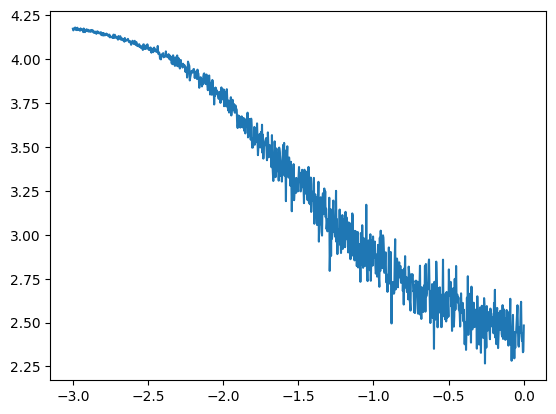

In [12]:
plt.plot(lri, lossi)

In [14]:
#create a batch
batch_size = 32
n_hidden = 100
steps = 200000
stepi = []
lossi = []
B = 0.9 #momentum value

for j in range(steps):
    ix = torch.randint(0, X_train.shape[0], (batch_size,))
    
    Xb = X_train[ix]
    Yb = Y_train[ix]
    
    hprev = torch.randn((batch_size,n_hidden))

    
    emb = C[Xb]
    total_loss = 0
    total_tokens = 0
    loss_manual = 0
    
    for i in range(context_size):
        input1 = emb[:,i,:]
        hpreact = input1 @ Wxh + hprev @ Whh + bx
        h = torch.tanh(hpreact)
        hprev = h
    
        logits = h @ Who + bo
        # counts = logits.exp()
        # probs = counts / counts.sum(0, keepdim = True)
        # logprobs = probs.log()
    
        target = Yb if i == (context_size-1) else Xb[:,i+1]
        # loss_manual += -logprobs[range(0,32),target].mean()
        total_loss += F.cross_entropy(logits, target, reduction ='sum')
        #print(f'timestep {i}\t manual = {loss_manual.item()}\t torch = {loss.item()}')
        total_tokens += batch_size

    loss = total_loss / total_tokens
    for p in parameters:
        p.grad = None
    loss.backward()
    
    lr = 0.25 if i<= 150000 else 0.025  
    for k in range(len(parameters)):   
        velocity[k] = B * velocity[k] + (1-B) * parameters[k].grad  #using momentum based gradient descent
        parameters[k].data += - lr * velocity[k]

    stepi.append(j)
    lossi.append(loss.item())
    if j % 10000 == 0:
        print(f'{j}/{steps}\t loss = {loss.item()}')
    #break

0/200000	 loss = 4.213024139404297
10000/200000	 loss = 1.9038188457489014
20000/200000	 loss = 1.871159553527832
30000/200000	 loss = 1.8567407131195068
40000/200000	 loss = 1.6766277551651
50000/200000	 loss = 1.768838882446289
60000/200000	 loss = 1.7821403741836548
70000/200000	 loss = 1.8449573516845703
80000/200000	 loss = 1.6468366384506226
90000/200000	 loss = 1.6683123111724854
100000/200000	 loss = 1.8236579895019531
110000/200000	 loss = 1.8739633560180664
120000/200000	 loss = 1.7328612804412842
130000/200000	 loss = 1.6846504211425781
140000/200000	 loss = 1.8000599145889282
150000/200000	 loss = 1.8439792394638062
160000/200000	 loss = 1.9281927347183228
170000/200000	 loss = 1.7054688930511475
180000/200000	 loss = 1.8197873830795288
190000/200000	 loss = 1.8370072841644287


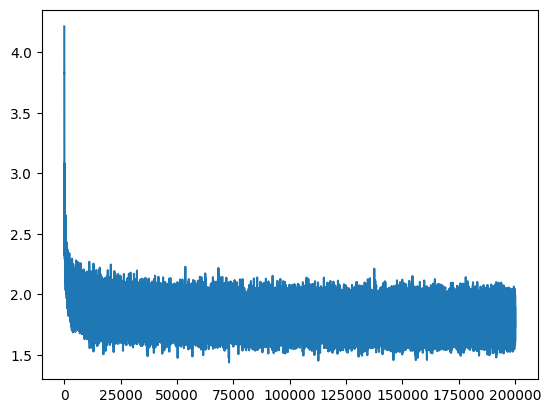

In [15]:
stepi = range(0,200000)

plt.plot(stepi,lossi)

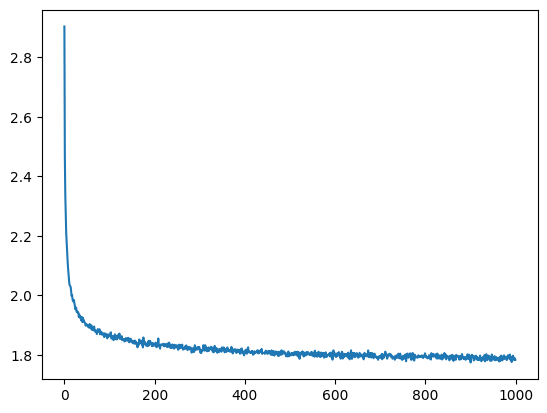

In [16]:
loss_new = torch.tensor(lossi)
loss_new = (loss_new.view(1000,-1)).mean(1, keepdim=True)
plt.plot(loss_new)


In [17]:
with torch.no_grad():
    def get_loss(split,batch_size = 32):
        x,y = {
            'train' : (X_train, Y_train),
            'val' : (X_val, Y_val),
            'test' : (X_test, Y_test)
        }[split]

        hprev = torch.zeros((batch_size,n_hidden))
        Xb = x[0:batch_size]
        Yb = y[0:batch_size]
        emb = C[Xb]
        total_loss = 0
        total_tokens = 0
        for i in range(context_size):
            input1 = emb[:,i,:]
            hpreact = input1 @ Wxh + hprev @ Whh + bx
            h = torch.tanh(hpreact)

            hprev = h
            
            logits = h @ Who + bo
            target =  Yb if i == (context_size-1) else Xb[:,i+1]
            total_loss +=  F.cross_entropy(logits, target, reduction='sum')
            total_tokens += batch_size

        loss = total_loss / total_tokens
        print(f'{split} loss = {loss.item()}')
            
    get_loss('train')
    get_loss('val')
    
            
        

train loss = 1.7001917362213135
val loss = 1.8761600255966187


In [20]:
Wxh.shape, bx.shape, Whh.shape, Who.shape

(torch.Size([12, 100]),
 torch.Size([1, 100]),
 torch.Size([100, 100]),
 torch.Size([100, 67]))

In [15]:
import os

print(os.listdir('/kaggle/working/'))


['.virtual_documents']


In [18]:
import torch
loaded_params = torch.load('/kaggle/input/weights/rnn_parameters.pth')

C = loaded_params['C']
Wxh = loaded_params['Wxh']
Whh = loaded_params['Whh']
Who = loaded_params['Who']
bx = loaded_params['bx']
bo = loaded_params['bo']

parameters = [C, Wxh, Whh, Who, bx, bo]

In [45]:
with torch.no_grad():
    def feed_context(word, hprev):
        tokenized_word = [stoi[char] for char in list(word)]
        emb = C[tokenized_word]
        for i in range(len(emb)):
            x = emb[i].unsqueeze(0)  # shape (1, n_embedd)
            hpreact = x @ Wxh + hprev @ Whh + bx
            hprev = torch.tanh(hpreact)
        return hprev

    def generate_next_char(h):
        y = h @ Who + bo
        probs = torch.softmax(y, dim=1)
        out = torch.multinomial(probs, num_samples=1)
        return itos[out.item()]

    def generate(word, num_char):
        n_hidden = 100
        hprev = torch.zeros((1, n_hidden))
        
        generated = []
        h = feed_context(word, hprev)
        
        for _ in range(num_char):
            # one-step prediction
            x_next = C[[stoi[generated[-1]]] if generated else [stoi[word[-1]]]]
            hpreact = x_next @ Wxh + h @ Whh + bx
            h = torch.tanh(hpreact)
            next_char = generate_next_char(h)
            generated.append(next_char)
        
        return word + "".join(generated)

    print(generate('Thy ', 10))


Thy  Quide not


In [39]:
params_dict = {
    'C' : C,
    'Wxh' : Wxh,
    'Whh' : Whh,
    'bx' : bx,
    'bo' : bo,
    'Who' : Who
}

torch.save(params_dict,'rnn_parameters.pth')

In [30]:
emb[0].shape, Wxh.shape,Whh.shape

(torch.Size([12]), torch.Size([12, 100]), torch.Size([100, 100]))

In [ ]:
#initial velocity = 0
# for each iteration update the velocity using B\

In [26]:
h.shape

torch.Size([7, 100])